Saving UAE cancer.csv to UAE cancer (2).csv

Descriptive Statistics - Age by Gender and Outcome:
                         count       mean        std   min    25%   50%   75%  \
Gender Outcome                                                                  
Female Deceased          502.0  53.276892  20.208223  18.0  37.25  53.0  70.0   
       Recovered        2543.0  54.130948  20.746052  18.0  36.00  55.0  72.0   
       Under Treatment  2128.0  53.860432  20.732332  18.0  36.00  54.0  72.0   
Male   Deceased          490.0  54.777551  21.239445  18.0  37.00  55.5  72.0   
       Recovered        2388.0  52.655779  20.819703  18.0  34.00  52.0  71.0   
       Under Treatment  1949.0  53.257568  20.717875  18.0  35.00  53.0  71.0   

                         max  
Gender Outcome                
Female Deceased         89.0  
       Recovered        89.0  
       Under Treatment  89.0  
Male   Deceased         89.0  
       Recovered        89.0  
       Under Treatment  89.0  


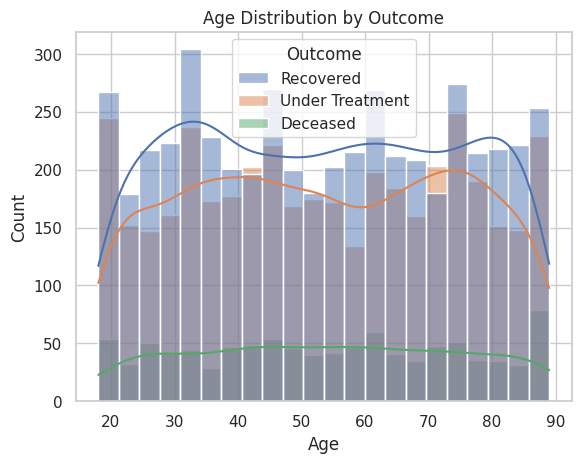

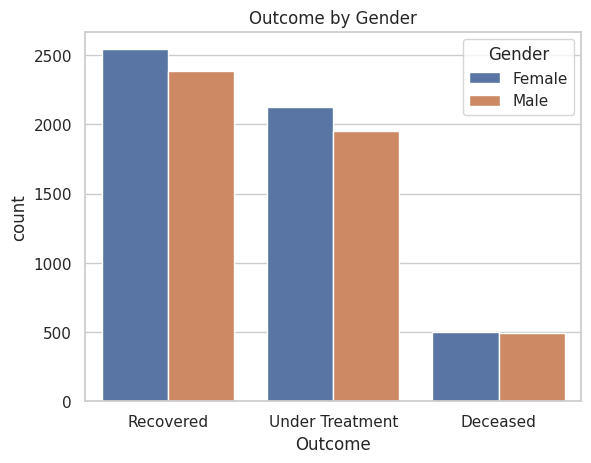

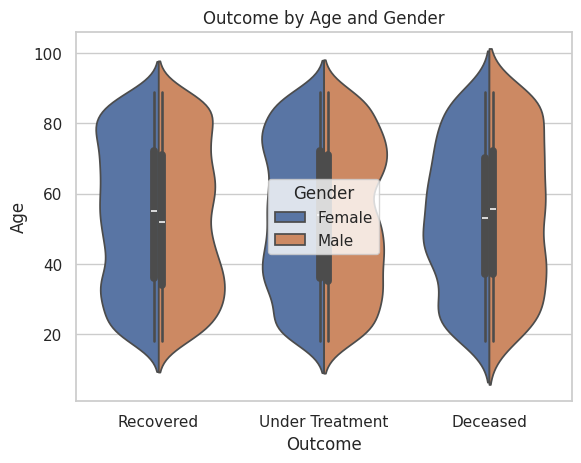


Chi-Square Test - Gender vs Outcome:
Chi2 = 0.9058475287294655 P-value = 0.6357665998495854
Contingency Table:
Outcome  Deceased  Recovered  Under Treatment
Gender                                       
Female        502       2543             2128
Male          490       2388             1949

Chi-Square Test - Age Group vs Outcome:
Chi2 = 5.551153802656279 P-value = 0.235269477567197
Contingency Table:
Outcome   Deceased  Recovered  Under Treatment
AgeGroup                                      
Under 40       282       1556             1235
40-59          294       1326             1130
60+            416       2049             1712

ANOVA - Age by Outcome:
F-statistic = 0.35526041505436373 P-value = 0.7009997203583367


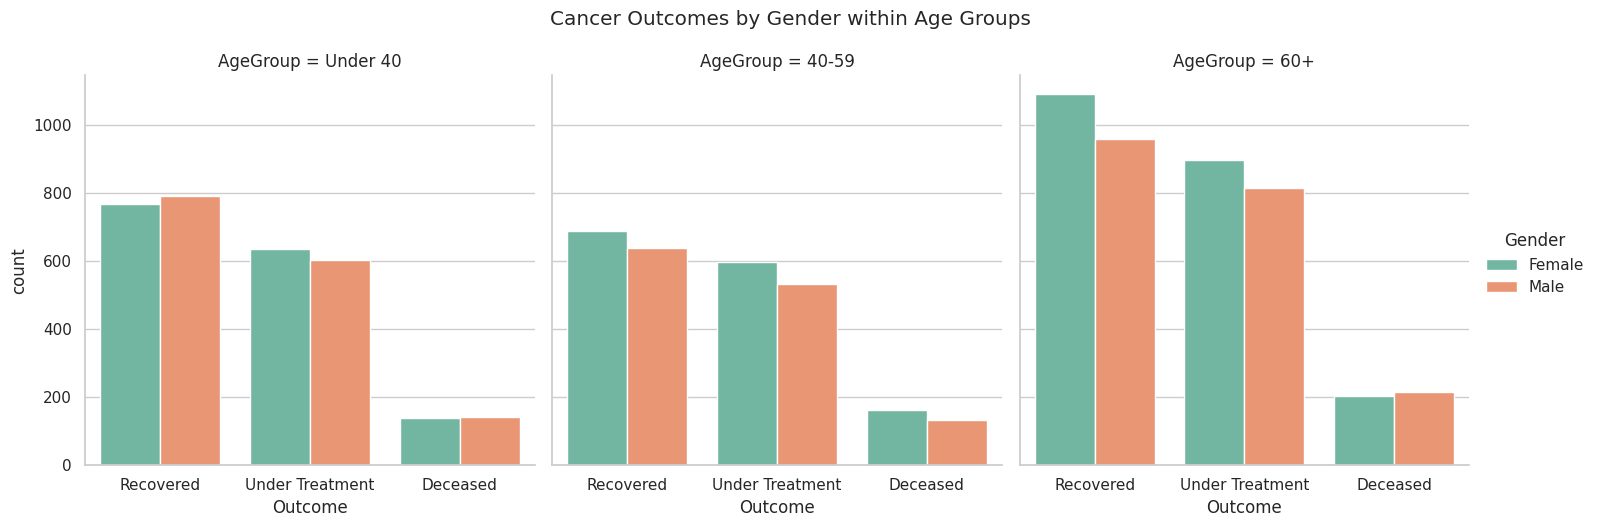


Chi-Square Test - Gender vs Outcome in Age Group '60+':
Chi2 = 2.984, p-value = 0.2250
Contingency Table:
Outcome  Deceased  Recovered  Under Treatment
Gender                                       
Female        202       1090              897
Male          214        959              815

Chi-Square Test - Gender vs Outcome in Age Group 'Under 40':
Chi2 = 1.301, p-value = 0.5219
Contingency Table:
Outcome  Deceased  Recovered  Under Treatment
Gender                                       
Female        139        766              634
Male          143        790              601

Chi-Square Test - Gender vs Outcome in Age Group '40-59':
Chi2 = 0.904, p-value = 0.6363
Contingency Table:
Outcome  Deceased  Recovered  Under Treatment
Gender                                       
Female        161        687              597
Male          133        639              533

Multinomial Logistic Regression - Coefficients and Odds Ratios:
                 Feature  Coefficient  Odds Ratio
0    

In [ ]:
# Cancer Outcome Disparities by Gender and Age in the UAE

# Upload dataset
from google.colab import files
uploaded = files.upload()  # Upload UAE cancer dataset

# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, f_oneway
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv("UAE cancer.csv")

# Convert date columns to datetime
date_cols = ['Diagnosis_Date', 'Treatment_Start_Date', 'Death_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Handle missing outcomes
df = df[df['Outcome'].notnull()]
df['Cause_of_Death'] = df['Cause_of_Death'].fillna("Unknown")

# One-hot encode categorical variables
categorical_cols = ['Gender', 'Cancer_Type', 'Cancer_Stage', 'Treatment_Type', 'Comorbidities',
                    'Smoking_Status', 'Ethnicity', 'Nationality', 'Emirate', 'Hospital', 'Primary_Physician']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Normalize continuous variables
scaler = MinMaxScaler()
df[['Age', 'Weight', 'Height']] = scaler.fit_transform(df[['Age', 'Weight', 'Height']])

# Create original age and age groups
df['Original_Age'] = scaler.inverse_transform(df[['Age', 'Weight', 'Height']])[:, 0]
df['AgeGroup'] = pd.cut(df['Original_Age'], bins=[0, 39, 59, 120], labels=['Under 40', '40-59', '60+'])

# Recreate Gender column
df['Gender'] = np.where(df['Gender_Male'] == 1, 'Male', 'Female')

# Descriptive stats for Age by Gender and Outcome
print("\nDescriptive Statistics - Age by Gender and Outcome:")
print(df.groupby(['Gender', 'Outcome'])['Original_Age'].describe())

# Histogram of Age by Outcome
sns.histplot(data=df, x='Original_Age', hue='Outcome', kde=True)
plt.title('Age Distribution by Outcome')
plt.xlabel('Age')
plt.show()

# Bar plot for Outcome by Gender
sns.countplot(data=df, x='Outcome', hue='Gender')
plt.title('Outcome by Gender')
plt.show()

# Violin plot by Gender and Age
sns.violinplot(x='Outcome', y='Original_Age', hue='Gender', data=df, split=True)
plt.title('Outcome by Age and Gender')
plt.ylabel('Age')
plt.show()

# Chi-square: Gender vs Outcome
contingency_table = pd.crosstab(df['Gender'], df['Outcome'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nChi-Square Test - Gender vs Outcome:")
print("Chi2 =", chi2, "P-value =", p)
print("Contingency Table:")
print(contingency_table)

# Chi-square: AgeGroup vs Outcome
contingency_table_age = pd.crosstab(df['AgeGroup'], df['Outcome'])
chi2_age, p_age, _, _ = chi2_contingency(contingency_table_age)
print("\nChi-Square Test - Age Group vs Outcome:")
print("Chi2 =", chi2_age, "P-value =", p_age)
print("Contingency Table:")
print(contingency_table_age)

# ANOVA - Age differences by Outcome
groups = [group['Original_Age'].values for name, group in df.groupby('Outcome')]
f_stat, p_val = f_oneway(*groups)
print("\nANOVA - Age by Outcome:")
print("F-statistic =", f_stat, "P-value =", p_val)

# Count plot: Outcomes by Gender within Age Groups
sns.set(style="whitegrid")
g = sns.catplot(
    data=df, kind="count",
    x="Outcome", hue="Gender",
    col="AgeGroup", palette="Set2"
)
g.fig.suptitle("Cancer Outcomes by Gender within Age Groups", y=1.05)
plt.show()

# Chi-square: Gender vs Outcome within each Age Group
age_groups = df['AgeGroup'].unique()
for group in age_groups:
    sub_df = df[df['AgeGroup'] == group]
    contingency = pd.crosstab(sub_df['Gender'], sub_df['Outcome'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    print(f"\nChi-Square Test - Gender vs Outcome in Age Group '{group}':")
    print(f"Chi2 = {chi2:.3f}, p-value = {p:.4f}")
    print("Contingency Table:")
    print(contingency)

# ---------------------------------------
# Multinomial Logistic Regression (Statistical Only without using ML)
# ---------------------------------------

# Encode target variable
le = LabelEncoder()
df['Outcome_Code'] = le.fit_transform(df['Outcome'])  # e.g., Deceased=0, Recovered=1, Under Treatment=2

# Select variables
features = ['Age', 'Gender_Male']
if 'Smoking_Status_Former Smoker' in df.columns:
    features.append('Smoking_Status_Former Smoker')
if 'Smoking_Status_Smoker' in df.columns:
    features.append('Smoking_Status_Smoker')

X = df[features]
y = df['Outcome_Code']

# Fit model on entire dataset
model = LogisticRegression(solver='lbfgs', max_iter=500)
model.fit(X, y)

# Coefficients and odds ratios
coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Odds Ratio': odds_ratios
})

print("\nMultinomial Logistic Regression - Coefficients and Odds Ratios:")
print(coef_df)

# In case if the code is not running because the file of the dataset was
# uploaded from my computer pleases refer to this page
https://github.com/t-alotaibi/HI-2454---Final-Project